In [1]:
import numpy as np
import pandas as pd
from datasets import load_dataset

from task6.utils.balance_dataset import augment_minority_classes
from task6.utils.prepare_data import prepare_data

C:\Projects\BUAS\Y2\block-a\fae2-nlpr-group-group-9-1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Szymon\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
dataset = load_dataset("google-research-datasets/go_emotions")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})

In [3]:
df = pd.DataFrame(dataset["train"])
df.head()

,text,labels,id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj


In [4]:
df, emotions = prepare_data(df, "text", "labels")
print(emotions)
df.head()

Detected dataset type: goemotions
Starting batch preprocessing...
✓ Text cleaning completed
✓ All NLP processing completed
['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'neutral']


,text,id,ekman_emotion,tokenized_text,lemmatized_text
0,My favourite food is anything I didn't have to...,eebbqej,6,"[my, favourite, food, is, anything, i, did, n'...","[my, favourite, food, be, anything, I, do, not..."
1,"Now if he does off himself, everyone will thin...",ed00q6i,6,"[now, if, he, does, off, himself, ,, everyone,...","[now, if, he, do, off, himself, ,, everyone, w..."
2,WHY THE FUCK IS BAYLESS ISOING,eezlygj,0,"[why, the, fuck, is, bayless, isoing]","[why, the, fuck, be, bayless, isoe]"
3,To make her feel threatened,ed7ypvh,2,"[to, make, her, feel, threatened]","[to, make, she, feel, threaten]"
4,Dirty Southern Wankers,ed0bdzj,0,"[dirty, southern, wankers]","[dirty, southern, wanker]"


In [5]:
df_test = pd.read_csv("../../data/transcript_spell_checked.csv")
df_test, emotions_test = prepare_data(df_test, "Translation", "emotion_final")

Detected dataset type: transcript
Starting batch preprocessing...
✓ Text cleaning completed
✓ All NLP processing completed


In [6]:
target_samples = 2500

classes_to_augment = df["ekman_emotion"].value_counts()[df["ekman_emotion"].value_counts() < target_samples].index.tolist()
print(f"Classes to augment: {classes_to_augment}")

Classes to augment: [2, 1]


In [7]:
df_augmented = augment_minority_classes(df, target_samples=target_samples, classes_to_augment=classes_to_augment)
df_augmented = pd.concat([df, df_augmented]).reset_index(drop=True)
print(df_augmented["ekman_emotion"].value_counts())
print(f"Original size: {len(df)}, Augmented size: {len(df_augmented)}")
df = df_augmented

Augmenting emotion 2: 691 → 2500
Augmenting emotion 1: 638 → 2500
Augmented Sample 1: thing be ... it be the medium the masse take in that be drive this anxiousness [ name ] operatingtheater ap reader be not fall for this
Augmented Sample 2: hither [ name ] here ... that guac look horrible
Augmented Sample 3: there be a war come , ned . I do non know when , I do non know worldhealthorganization we will be fight ... but it be come !
ekman_emotion
3    16920
6    12823
0     5579
5     4160
4     2599
2     2500
1     2500
Name: count, dtype: int64
Original size: 43410, Augmented size: 47081


In [8]:
df["lemmatized_text"] = df["lemmatized_text"].apply(lambda tokens: " ".join(tokens))
df_test["lemmatized_text"] = df_test["lemmatized_text"].apply(lambda tokens: " ".join(tokens))

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_word = TfidfVectorizer(max_features=40000, ngram_range=(1, 2))
tfidf_word = vectorizer_word.fit_transform(df["lemmatized_text"])
tfidf_word_test = vectorizer_word.transform(df_test["lemmatized_text"])

In [10]:
from transformers import pipeline

# sentiment analysis
sentiment = pipeline("sentiment-analysis", model="cardiffnlp/twitter-xlm-roberta-base-sentiment", top_k=None)

Device set to use cuda:0


In [35]:
def analyze_sentiment_batch(texts, max_len=500):
    # Trim all texts upfront
    trimmed_texts = [
        t[:max_len] if isinstance(t, str) and len(t) > max_len else t
        for t in texts
    ]

    # Run through the pipeline in batches
    results = sentiment(trimmed_texts, batch_size=256)

    numeric_scores = []
    for result in results:
        best = max(result, key=lambda x: x["score"])
        label = best["label"]
        conf = best["score"]

        if label == "negative":
            numeric_scores.append(-conf)
        elif label == "neutral":
            numeric_scores.append(0.0)
        elif label == "positive":
            numeric_scores.append(conf)
        else:
            numeric_scores.append(0.0)

    return numeric_scores

In [36]:
df["sentiment_score"] = analyze_sentiment_batch(df["lemmatized_text"].tolist())
df_test["sentiment_score"] = analyze_sentiment_batch(df_test["lemmatized_text"].tolist())

KeyboardInterrupt: 

In [13]:
# Intensity markers count: occurrences of "very", "so", "extremely" and other similar words
intensity_markers = ["very", "so", "extremely", "highly", "too", "really", "absolutely", "completely", "totally", "utterly"]
df["intensity_marker_count"] = df["lemmatized_text"].apply(lambda x: sum(x.lower().count(marker) for marker in intensity_markers))
df_test["intensity_marker_count"] = df_test["lemmatized_text"].apply(lambda x: sum(x.lower().count(marker) for marker in intensity_markers))

In [14]:
# load emotion lexicon
emotion_lexicon = pd.read_csv("../../data/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt", sep="\t", names=["word", "emotion", "association"])
# pivot the lexicon to have emotions as columns
emotion_lexicon_pivot = emotion_lexicon.pivot(index="word", columns="emotion", values="association").fillna(0)
# create a dictionary for faster lookup
emotion_dict = emotion_lexicon_pivot.to_dict(orient="index")

In [15]:
def return_emotion_counts(lemmas_str):
    lemmas = lemmas_str.lower().split()
    counts = {emotion: 0 for emotion in emotion_lexicon_pivot.columns}

    for lemma in lemmas:
        if lemma in emotion_dict:
            for emotion in emotion_dict[lemma]:
                # increment only emotions marked 1
                if emotion_dict[lemma][emotion] == 1:
                    counts[emotion] += 1

    return pd.Series(counts)

In [16]:
emotion_counts = df["lemmatized_text"].apply(return_emotion_counts)
df = pd.concat([df, emotion_counts], axis=1)

In [17]:
emotion_counts = df_test["lemmatized_text"].apply(return_emotion_counts)
df_test = pd.concat([df_test, emotion_counts], axis=1)

In [18]:
# calculate number of tokens, ratio of unique tokens to total tokens, average word length
df["num_tokens"] = df["lemmatized_text"].apply(lambda x: len(x.split()))
df["unique_token_ratio"] = df["lemmatized_text"].apply(lambda x: len(set(x.split())) / len(x.split()) if len(x.split()) > 0 else 0)
df["avg_word_length"] = df["lemmatized_text"].apply(lambda x: np.mean([len(word) for word in x.split()]) if len(x.split()) > 0 else 0)
df_test["num_tokens"] = df_test["lemmatized_text"].apply(lambda x: len(x.split()))
df_test["unique_token_ratio"] = df_test["lemmatized_text"].apply(lambda x: len(set(x.split())) / len(x.split()) if len(x.split()) > 0 else 0)
df_test["avg_word_length"] = df_test["lemmatized_text"].apply(lambda x: np.mean([len(word) for word in x.split()]) if len(x.split()) > 0 else 0)

In [19]:
# calculate punctuation count
import string
df["punctuation_count"] = df["lemmatized_text"].apply(lambda x: sum([1 for char in x if char in string.punctuation]))
df_test["punctuation_count"] = df_test["lemmatized_text"].apply(lambda x: sum([1 for char in x if char in string.punctuation]))

In [20]:
# Negation feature: binary if any negation word in window of previous 3 tokens
negation_words = set(["not", "no", "never", "n't", "none", "nobody", "nothing", "neither", "nowhere", "hardly", "scarcely", "barely", "doesn't", "isn't", "wasn't", "shouldn't", "wouldn't", "couldn't", "won't", "can't", "don't"])
def negation_feature(text):
    tokens = text.split()
    return 1 if any(token in negation_words for token in tokens) else 0
df["negation"] = df["lemmatized_text"].apply(negation_feature)
df_test["negation"] = df_test["lemmatized_text"].apply(negation_feature)

In [21]:
from sklearn.preprocessing import StandardScaler
additional_features = df[["sentiment_score", "intensity_marker_count", "num_tokens",
                         "unique_token_ratio", "avg_word_length", "punctuation_count",
                         "negation"] + list(emotion_lexicon_pivot.columns)]

scaler = StandardScaler()
additional_features_scaled = scaler.fit_transform(additional_features)
additional_features_test_scaled = scaler.transform(df_test[["sentiment_score", "intensity_marker_count", "num_tokens",
                                                            "unique_token_ratio", "avg_word_length", "punctuation_count",
                                                            "negation"] + list(emotion_lexicon_pivot.columns)])

In [22]:
from scipy.sparse import hstack, csr_matrix

X_train = hstack([tfidf_word, csr_matrix(additional_features_scaled)])
X_test = hstack([tfidf_word_test, csr_matrix(additional_features_test_scaled)])

In [23]:
y_train = df["ekman_emotion"]
y_test = df_test["ekman_emotion"]
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (47081, 40017), y_train shape: (47081,)
X_test shape: (914, 40017), y_test shape: (914,)


In [24]:
n_samples, n_features = X_train.shape
dual_choice = False if n_samples > n_features else False

In [25]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import RandomizedSearchCV

In [26]:
param_grid = {
    "C": [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
    "max_iter": [15000, 20000, 25000, 30000],
    "class_weight": [None, "balanced"],
    "loss": ["hinge", "squared_hinge"],
    "penalty": ["l2"]  # L1 penalty often causes issues with LinearSVC
}

randomized_search = RandomizedSearchCV(
    LinearSVC(random_state=42, dual=dual_choice),
    param_grid,
    cv=3,
    n_jobs=12,
    verbose=2,
    n_iter=50,
    scoring='f1_macro',
    random_state=42,
    return_train_score=True
)

randomized_search.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


C:\Projects\BUAS\Y2\block-a\fae2-nlpr-group-group-9-1\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
81 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
81 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Projects\BUAS\Y2\block-a\fae2-nlpr-group-group-9-1\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Projects\BUAS\Y2\block-a\fae2-nlpr-group-group-9-1\.venv\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Pr

,estimator,LinearSVC(dua...ndom_state=42)
,param_distributions,"{'C': [0.001, 0.01, ...], 'class_weight': [None, 'balanced'], 'loss': ['hinge', 'squared_hinge'], 'max_iter': [15000, 20000, ...], ...}"
,n_iter,50
,scoring,'f1_macro'
,n_jobs,12
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [27]:
print("\n" + "="*50)
print("RANDOMIZED SEARCH RESULTS")
print("="*50)
print(f"Best parameters: {randomized_search.best_params_}")
print(f"Best CV score: {randomized_search.best_score_:.4f}")
print(f"Best estimator: {randomized_search.best_estimator_}")


RANDOMIZED SEARCH RESULTS
Best parameters: {'penalty': 'l2', 'max_iter': 25000, 'loss': 'squared_hinge', 'class_weight': 'balanced', 'C': 0.5}
Best CV score: 0.6477
Best estimator: LinearSVC(C=0.5, class_weight='balanced', dual=False, max_iter=25000,
          random_state=42)


In [28]:
from sklearn.model_selection import GridSearchCV

In [29]:
param_grid = {
    'C': np.arange(0.1, 0.8, 0.05).tolist(),
    'max_iter': [30000],
    'class_weight': ['balanced', None],
    'loss': ['squared_hinge'],
    'penalty': ['l2']
}

grid_search = GridSearchCV(
    LinearSVC(random_state=42, dual=dual_choice),
    param_grid,
    cv=3,
    n_jobs=12,
    verbose=2,
    scoring='f1_macro',
    return_train_score=True
)
print("Starting grid search...")
grid_search.fit(X_train, y_train)
print("\n" + "="*50)
print("GRID SEARCH RESULTS")
print("="*50)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")
print(f"Best estimator: {grid_search.best_estimator_}")

Starting grid search...
Fitting 3 folds for each of 28 candidates, totalling 84 fits

GRID SEARCH RESULTS
Best parameters: {'C': 0.30000000000000004, 'class_weight': 'balanced', 'loss': 'squared_hinge', 'max_iter': 30000, 'penalty': 'l2'}
Best CV score: 0.6496
Best estimator: LinearSVC(C=0.30000000000000004, class_weight='balanced', dual=False,
          max_iter=30000, random_state=42)


In [30]:
best_params = grid_search.best_params_
svm_model = LinearSVC(**best_params, random_state=42, dual=dual_choice)
svm_model.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,False
,tol,0.0001
,C,0.30000000000000004
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,verbose,0
,random_state,42


In [31]:
from sklearn.metrics import classification_report
y_pred = svm_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=emotions_test, zero_division=0, digits=3))

Classification Report:
              precision    recall  f1-score   support

       anger      0.514     0.500     0.507       150
     disgust      0.286     0.045     0.078        44
        fear      1.000     0.195     0.327        41
         joy      0.730     0.516     0.604       225
     sadness      0.567     0.148     0.234       115
    surprise      0.296     0.296     0.296        81
     neutral      0.391     0.733     0.510       258

    accuracy                          0.472       914
   macro avg      0.540     0.348     0.365       914
weighted avg      0.531     0.472     0.450       914



In [32]:
# print random misclassified examples with emotion labels
import random
misclassified_indices = np.where(y_test != y_pred)[0]
random_indices = random.sample(list(misclassified_indices), min(5, len(misclassified_indices)))
for idx in random_indices:
    print(f"Text: {df_test.iloc[idx]['lemmatized_text']}")
    print(f"True label (name): {emotions_test[y_test.iloc[idx]]}, Predicted label (name): {emotions_test[y_pred[idx]]}")
    print("-"*50)

Text: I know that it already have some incident
True label (name): fear, Predicted label (name): surprise
--------------------------------------------------
Text: but they already ask we like that .
True label (name): sadness, Predicted label (name): neutral
--------------------------------------------------
Text: photo , autograph ,
True label (name): joy, Predicted label (name): neutral
--------------------------------------------------
Text: but I do not buy such joke .
True label (name): disgust, Predicted label (name): joy
--------------------------------------------------
Text: how be you feel ?
True label (name): neutral, Predicted label (name): surprise
--------------------------------------------------


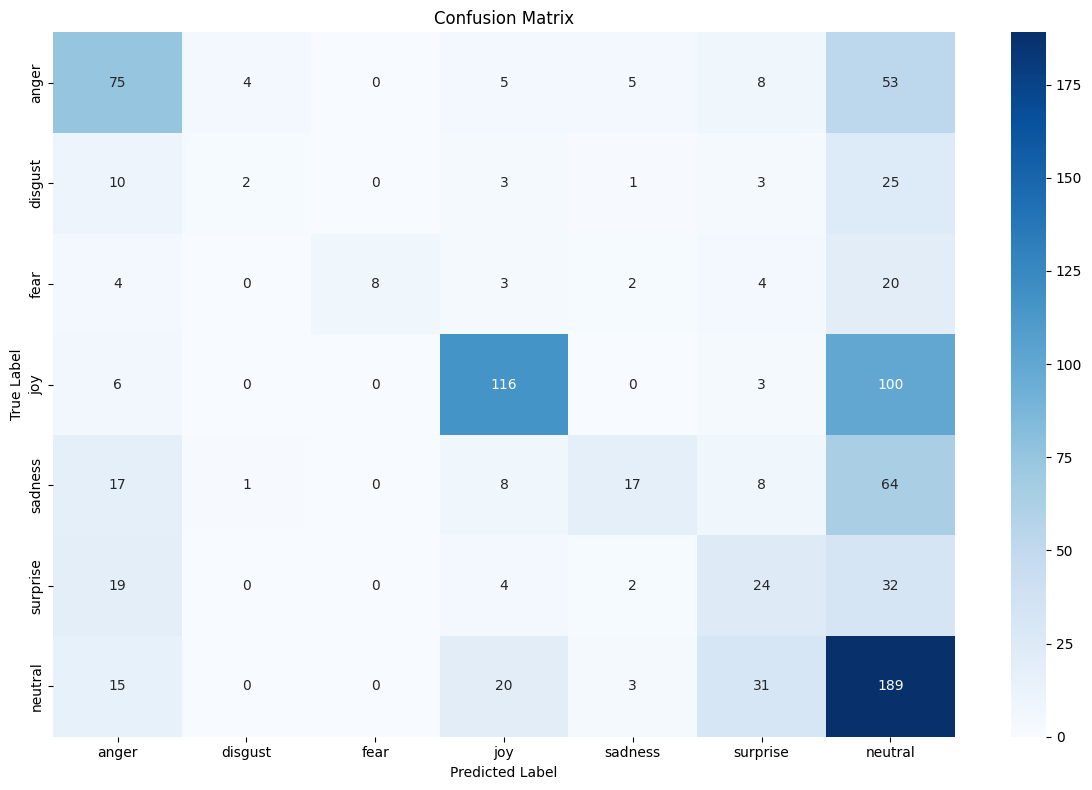

Classification Report:
              precision    recall  f1-score   support

       anger       0.51      0.50      0.51       150
     disgust       0.29      0.05      0.08        44
        fear       1.00      0.20      0.33        41
         joy       0.73      0.52      0.60       225
     sadness       0.57      0.15      0.23       115
    surprise       0.30      0.30      0.30        81
     neutral       0.39      0.73      0.51       258

    accuracy                           0.47       914
   macro avg       0.54      0.35      0.37       914
weighted avg       0.53      0.47      0.45       914


Top 7 Error Patterns:
------------------------------
joy → neutral: 100 (20.7% of errors)
sadness → neutral: 64 (13.3% of errors)
anger → neutral: 53 (11.0% of errors)
surprise → neutral: 32 (6.6% of errors)
neutral → surprise: 31 (6.4% of errors)
disgust → neutral: 25 (5.2% of errors)
fear → neutral: 20 (4.1% of errors)

Per-Class Performance:
------------------------------
a

In [34]:
from task6.utils.error_analysis import analyze_classification_errors

results = analyze_classification_errors(
    y_true=y_test,
    y_pred=y_pred,
    class_names=emotions_test,
    sample_texts=df_test["lemmatized_text"],
    model=svm_model,
    X_test=X_test,
    top_k_errors=5
)